In [1]:
import scipy.io as io
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import uncertainties as unc
import uncertainties.unumpy as unp

In [2]:
import matplotlib
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)

In [3]:
%matplotlib notebook

In [4]:
font = {'family' : 'Microsoft Sans Serif',
        'weight' : 'bold',
        'size'   : 8}

matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=0.5, edgecolor='k')

In [5]:
data_exp = np.load('TD_mw2mw_ggee.npy', allow_pickle=True)
data_fits_g = np.load('TD_mw2mw_fits_gg.npy')
data_fits_e = np.load('TD_mw2mw_fits_ee.npy', allow_pickle=True)
data_fb = np.load('TD_mw2mw_fillbtw_ggee.npy')

<IPython.core.display.Javascript object>


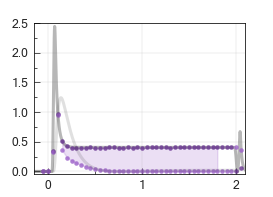

In [6]:
colors = ['#66318F', '#75ba77', '#c43b3b', '#e36d7a', '#333333']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 0.8
rang = range(3,37)


ax1.plot((data_fits_g[0]-620)/1000, data_fits_g[1]*1e5, color=colors[4], lw=2, alpha=0.35)
#ax1.plot((data_fits_e[0][:500]-620)/1000, data_fits_e[1][:500]*1e5, color=colors[4], lw=2, alpha=0.3)
# ax1.plot(data_exp[0][0]/1000, data_exp[0][1]*1e5, color=colors[0], lw=lw, label='|g>')
# ax1.plot(data_exp[1][0]/1000, data_exp[1][1]*1e5, color=colors_light[0], lw=lw, label='|e>')
#ax1.plot(data_exp[0][0]/1000, data_exp[0][1]*1e5, '.', mec=colors[0], ms=ms, mew = 0, mfc=colors[0], alpha=0.8)
ax1.plot(data_exp[1][0]/1000, data_exp[0][1]*1e5, '.', mec=colors[0], ms=ms, mew = 0, mfc=colors[0], alpha=0.8)
ax1.plot(data_exp[1][0]/1000, data_exp[1][1]*1e5, '.', mec=colors_light[0], ms=ms, mew = 0, mfc=colors_light[0], alpha=0.8)

ax1.fill_between(data_fb[0][rang]/1000, data_fb[1][rang]*1e5, data_fb[2][rang]*1e5, color=colors_light[0], alpha=0.2)

ax1.plot((data_fits_e[0][200:1100]-620)/1000, data_fits_e[1][200:1100]*1e5, color=colors[4], lw=2, alpha=0.15)

ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

ax1.set_xlim([-0.15,2.1])
ax1.set_ylim([-0.05,2.5])
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

ax1.yaxis.set_major_locator(MultipleLocator(0.5))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.yaxis.set_minor_locator(MultipleLocator(0.25))

# plt.savefig('fig2_mwmw.pdf')
# plt.savefig('fig2_mwmw.svg')

In [7]:
data_exp = np.load('TD_mw2opt_ggee.npy')
data_fits_gg = np.load('TD_mw2opt_fits_gg.npy')
data_fits_ee = np.load('TD_mw2opt_fits_ee.npy')
data_fb = np.load('TD_mw2opt_fillbtw_ggee.npy')[0]

<IPython.core.display.Javascript object>


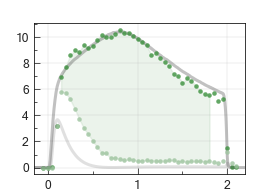

In [8]:
colors = ['#66318F', '#3c913e', '#c43b3b', '#e36d7a', '#333333']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 0.8
rang = range(3, len(data_fb[0]))


ax1.plot((data_fits_gg[0]-665)/1000, data_fits_gg[1]*1e4, color=colors[4], lw=2, alpha=0.3)


# ax1.plot(data_exp[0][0]/1000, data_exp[0][1]*1e4, color=colors[1], lw=lw, label='|g>')
# ax1.plot(data_exp[1][0]/1000, data_exp[1][1]*1e4, color=colors_light[1], lw=lw, label='|e>')
ax1.plot(data_exp[0][0]/1000, data_exp[0][1]*1e4, '.', mec=colors[1], ms=ms, mew = 0, mfc=colors[1], alpha=0.8)
ax1.plot(data_exp[1][0]/1000, data_exp[1][1]*1e4, '.', mec=colors_light[1], ms=ms, mew = 0, mfc=colors_light[1], alpha=0.8)

ax1.fill_between(data_fb[0][rang]/1000, data_fb[1][rang]*1e4, data_fb[2][rang]*1e4, color=colors_light[1], alpha=0.2)

ax1.plot((data_fits_ee[0][200:1150]-655)/1000, data_fits_ee[1][200:1150]*1e4, color=colors[4], lw=2, alpha=0.15)


ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

ax1.set_xlim([-0.15,2.2])
# ax1.set_ylim([-0.05,2.3])
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

ax1.yaxis.set_major_locator(MultipleLocator(2))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.yaxis.set_minor_locator(MultipleLocator(1))
plt.show()
# plt.savefig('fig2_mwopt.pdf')
# plt.savefig('fig2_mwopt.svg')

In [9]:
data_exp = np.load('TD_opt2opt_ggee.npy')
data_fits_g = np.load('TD_opt2opt_fits_gg.npy')
data_fits_e = np.load('TD_opt2opt_fits_ee.npy')
data_fb = np.load('TD_opt2opt_fillbtw_ggee.npy')
data_fits_dba = np.load('TD_opt2opt_fits_dba.npy')

<IPython.core.display.Javascript object>


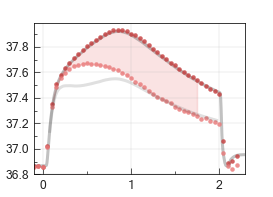

In [10]:
colors = ['#66318F', '#3c913e', '#c43b3b', '#e36d7a', '#333333']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 0.8
rang = range(3, len(data_fb[0]))


ax1.plot((data_fits_g[0]-635)/1000, data_fits_g[1], color=colors[4], lw=2, alpha=0.3)


# ax1.plot(data_exp[0][0]/1000, data_exp[0][1], color=colors[2], lw=lw, label='|g>')
# ax1.plot(data_exp[1][0]/1000, data_exp[1][1], color=colors_light[2], lw=lw, label='|e>')
ax1.plot(data_exp[0][0]/1000, data_exp[0][1], '.', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.8)
ax1.plot(data_exp[1][0]/1000, data_exp[1][1], '.', mec=colors_light[2], ms=ms, mew = 0, mfc=colors_light[2], alpha=0.8)

ax1.fill_between(data_fb[0][rang]/1000, data_fb[1][rang], data_fb[2][rang], color=colors_light[2], alpha=0.2)
ax1.plot((data_fits_e[0][200:1000]-635)/1000, data_fits_e[1][200:1000], color=colors[4], lw=2, alpha=0.15)



ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

ax1.set_xlim([-0.1,2.3])
ax1.set_ylim(bottom=36.8)
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

ax1.yaxis.set_major_locator(MultipleLocator(0.2))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.yaxis.set_minor_locator(MultipleLocator(0.1))

plt.show()
# plt.savefig('fig2_optopt.pdf')
# plt.savefig('fig2_optopt.svg')

<IPython.core.display.Javascript object>


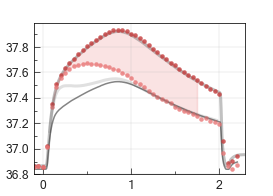

In [12]:
colors = ['#66318F', '#3c913e', '#c43b3b', '#e36d7a', '#333333']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 0.8
rang = range(3, len(data_fb[0]))


ax1.plot((data_fits_g[0]-635)/1000, data_fits_g[1], color=colors[4], lw=2, alpha=0.3)
ax1.plot((data_fits_dba[0][100:1100]-635)/1000, data_fits_dba[1][100:1100], color=colors[4], lw=1, alpha=0.6)


# ax1.plot(data_exp[0][0]/1000, data_exp[0][1], color=colors[2], lw=lw, label='|g>')
# ax1.plot(data_exp[1][0]/1000, data_exp[1][1], color=colors_light[2], lw=lw, label='|e>')
ax1.plot(data_exp[0][0]/1000, data_exp[0][1], '.', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.8)
ax1.plot(data_exp[1][0]/1000, data_exp[1][1], '.', mec=colors_light[2], ms=ms, mew = 0, mfc=colors_light[2], alpha=0.8)

ax1.fill_between(data_fb[0][rang]/1000, data_fb[1][rang], data_fb[2][rang], color=colors_light[2], alpha=0.2)
ax1.plot((data_fits_e[0][200:1000]-635)/1000, data_fits_e[1][200:1000], color=colors[4], lw=2, alpha=0.15)



ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

ax1.set_xlim([-0.1,2.3])
ax1.set_ylim(bottom=36.8)
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

ax1.yaxis.set_major_locator(MultipleLocator(0.2))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.yaxis.set_minor_locator(MultipleLocator(0.1))
plt.show()
# plt.savefig('fig2_optopt_dba.pdf')
# plt.savefig('fig2_optopt_dba.svg')

<IPython.core.display.Javascript object>


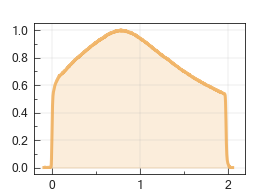

In [13]:
pump = np.genfromtxt(r'.\2023_02_13_rect_2000ns_SGMA1400EDFA_exp-0.00085_23p2dBmWindAOM_CH1.txt')
pumprefl = np.genfromtxt(r'.\2023_02_13_rect_2000ns_SGMA1400EDFA_exp-0.00085_23p2dBmWindAOM_CH2.txt')

mwconvstart = 2640
optconvstart = 2940
optpumpstart = 3864

t = np.arange(0,20000,0.25) #time array in ns
timestep = t[1] - t[0]
pump = pump - np.mean(pump[:1000])
pump[pump<0]=0
pump = pump/np.amax(pump)
pumprefl = pumprefl - np.mean(pumprefl[:1000])
pumprefl[pumprefl<0]=0
pumprefl = pumprefl/np.amax(pumprefl)
t_pump = np.arange(len(pump))
t_pump = t_pump*2.37
pump = pump[t_pump>0]
pumprefl = pumprefl[t_pump>0]

f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 0.8
#rang = range(3, len(data_fb[0]))


ax1.plot(t_pump[1600:2505]/1000-3.880, pump[1600:2505], color='#EFA94F', lw=2, alpha=0.8)
ax1.fill_between(t_pump[1600:2505]/1000-3.880,pump[1600:2505],np.zeros(2505-1600), color='#EFA94F', alpha=0.2)
#ax1.plot(t_pump[1:]-3880, pumprefl, color=colors[4], lw=1, alpha=0.6)


ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

ax1.set_xlim([-200/1000,2200/1000])
#ax1.set_ylim(bottom=36.8)
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

ax1.yaxis.set_major_locator(MultipleLocator(0.2))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.yaxis.set_minor_locator(MultipleLocator(0.1))

# plt.savefig('fig2_opt_pump.pdf')
# plt.savefig('fig2_opt_pump.svg')

<IPython.core.display.Javascript object>


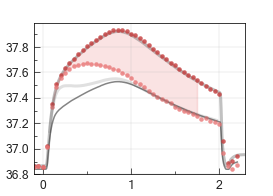

In [14]:
colors = ['#66318F', '#3c913e', '#c43b3b', '#e36d7a', '#333333']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 6
mew = 0.4
lw = 0.8
rang = range(3, len(data_fb[0]))


ax1.plot((data_fits_g[0]-635)/1000, data_fits_g[1], color=colors[4], lw=2, alpha=0.3)
ax1.plot((data_fits_dba[0][100:1100]-635)/1000, data_fits_dba[1][100:1100], color=colors[4], lw=1, alpha=0.6)


# ax1.plot(data_exp[0][0]/1000, data_exp[0][1], color=colors[2], lw=lw, label='|g>')
# ax1.plot(data_exp[1][0]/1000, data_exp[1][1], color=colors_light[2], lw=lw, label='|e>')
ax1.plot(data_exp[0][0]/1000, data_exp[0][1], '.', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.8)
ax1.plot(data_exp[1][0]/1000, data_exp[1][1], '.', mec=colors_light[2], ms=ms, mew = 0, mfc=colors_light[2], alpha=0.8)

ax1.fill_between(data_fb[0][rang]/1000, data_fb[1][rang], data_fb[2][rang], color=colors_light[2], alpha=0.2)
ax1.plot((data_fits_e[0][200:1000]-635)/1000, data_fits_e[1][200:1000], color=colors[4], lw=2, alpha=0.15)



ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

ax1.set_xlim([-0.1,2.3])
ax1.set_ylim(bottom=36.8)
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

ax1.yaxis.set_major_locator(MultipleLocator(0.2))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.yaxis.set_minor_locator(MultipleLocator(0.1))

# plt.savefig('fig2_optopt_dba.pdf')
# plt.savefig('fig2_optopt_dba.svg')

In [16]:
data_exp = np.load('hist_MW2MW.npy')
data_fits = np.load('hist_MW2MW_fits.npy')

<IPython.core.display.Javascript object>


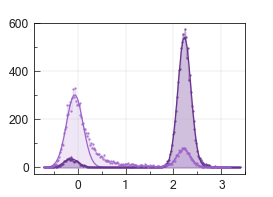

In [17]:
colors = ['#66318F', '#3c913e', '#c43b3b', '#e36d7a', '#333333']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 3
mew = 0.4
lw = 0.8


# ax1.plot((data_fits_g[0]-635)/1000, data_fits_g[1], color=colors[4], lw=2, alpha=0.3)

ax1.plot(data_fits[0][0]*1e6, data_fits[0][1], color=colors_light[0], lw=lw, label='|g>')
ax1.plot(data_fits[1][0]*1e6, data_fits[1][1], color=colors[0], lw=lw, label='|e>')
ax1.plot(data_exp[0][0]*1e6, data_exp[0][1], '.', mec=colors[0], ms=ms, mew = 0, mfc=colors[0], alpha=0.8)
ax1.plot(data_exp[1][0]*1e6, data_exp[1][1], '.', mec=colors_light[0], ms=ms, mew = 0, mfc=colors_light[0], alpha=0.8)

# ax1.fill_between(data_fits[0][0]*1e6, 0, data_fits[0][1], color=colors_light[0], alpha=0.15)
# ax1.fill_between(data_fits[1][0]*1e6, 0, data_fits[1][1], color=colors[0], alpha=0.3)

ax1.fill_between(data_exp[0][0]*1e6, 0, data_exp[0][1], color=colors[0], alpha=0.3)
ax1.fill_between(data_exp[1][0]*1e6, 0, data_exp[1][1], color=colors_light[0], alpha=0.15)

ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

ax1.set_xlim(right=3.5)
ax1.set_ylim(top=600)
ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(0.5))

ax1.yaxis.set_major_locator(MultipleLocator(200))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.yaxis.set_minor_locator(MultipleLocator(100))
plt.show()
# plt.savefig('fig2_mwmw_hist.pdf')

In [20]:
data_exp = np.load('hist_MW2opt.npy')
data_fits = np.load('hist_MW2opt_fits.npy')

<IPython.core.display.Javascript object>


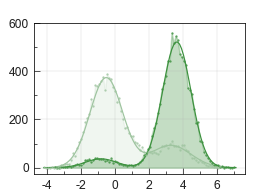

In [21]:
colors = ['#66318F', '#3c913e', '#c43b3b', '#e36d7a', '#333333']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 3
mew = 0.4
lw = 0.8


# ax1.plot((data_fits_g[0]-635)/1000, data_fits_g[1], color=colors[4], lw=2, alpha=0.3)

ax1.plot(data_fits[0][0]*1e4, data_fits[0][1], color=colors_light[1], lw=lw, label='|g>')
ax1.plot(data_fits[1][0]*1e4, data_fits[1][1], color=colors[1], lw=lw, label='|e>')
ax1.plot(data_exp[0][0]*1e4, data_exp[0][1], '.', mec=colors[1], ms=ms, mew = 0, mfc=colors[1], alpha=0.8)
ax1.plot(data_exp[1][0]*1e4, data_exp[1][1], '.', mec=colors_light[1], ms=ms, mew = 0, mfc=colors_light[1], alpha=0.8)

ax1.fill_between(data_exp[0][0]*1e4, 0, data_exp[0][1], color=colors[1], alpha=0.3)
ax1.fill_between(data_exp[1][0]*1e4, 0, data_exp[1][1], color=colors_light[1], alpha=0.15)

ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

# ax1.set_xlim(right=3.5)
ax1.set_ylim(top=600)
ax1.xaxis.set_major_locator(MultipleLocator(2))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.xaxis.set_minor_locator(MultipleLocator(1))

ax1.yaxis.set_major_locator(MultipleLocator(200))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.yaxis.set_minor_locator(MultipleLocator(100))
plt.show()
# plt.savefig('fig2_mwopt_hist.pdf')

In [23]:
data_exp = np.load('hist_opt2opt.npy')
data_fits = np.load('hist_opt2opt_fits.npy')

<IPython.core.display.Javascript object>


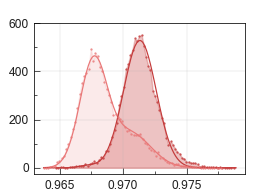

In [25]:
colors = ['#66318F', '#3c913e', '#c43b3b', '#e36d7a', '#333333']
colors_light = ['#9c61c9', '#9EC49F', '#E97777', '#e36d7a']
f, ax1 = plt.subplots(1,1, figsize=(2.5,1.8))
# f, ax1 = plt.subplots(1,1, figsize=(9,6))



ms = 3
mew = 0.4
lw = 0.8


# ax1.plot((data_fits_g[0]-635)/1000, data_fits_g[1], color=colors[4], lw=2, alpha=0.3)

ax1.plot(data_fits[0][0], data_fits[0][1], color=colors_light[2], lw=lw, label='|g>')
ax1.plot(data_fits[1][0], data_fits[1][1], color=colors[2], lw=lw, label='|e>')
ax1.plot(data_exp[0][0], data_exp[0][1], '.', mec=colors[2], ms=ms, mew = 0, mfc=colors[2], alpha=0.8)
ax1.plot(data_exp[1][0], data_exp[1][1], '.', mec=colors_light[2], ms=ms, mew = 0, mfc=colors_light[2], alpha=0.8)

ax1.fill_between(data_exp[0][0], 0, data_exp[0][1], color=colors[2], alpha=0.3)
ax1.fill_between(data_exp[1][0], 0, data_exp[1][1], color=colors_light[2], alpha=0.15)

ax1.grid(linewidth = 0.3, alpha=0.5)

color = '#242424'
ax1.xaxis.label.set_color(color)
ax1.tick_params(axis='x', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='x', which='minor', color=color, width=0.5, direction='in', length=2)
ax1.yaxis.label.set_color(color)
ax1.tick_params(axis='y', colors=color, direction="in", width=0.5, length=4)
ax1.tick_params(axis='y', which='minor', color=color, width=0.5, direction='in', length=2)
plt.tick_params(axis="both", which="both", bottom=True, top=False,    
                labelbottom=True, left=True, right=False, labelleft=True, width=0.5)

# plt.legend()

# ax1.set_xlim(right=3.5)
ax1.set_ylim(top=600)
ax1.xaxis.set_major_locator(MultipleLocator(0.005))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax1.xaxis.set_minor_locator(MultipleLocator(0.0025))

ax1.yaxis.set_major_locator(MultipleLocator(200))
ax1.yaxis.set_major_formatter(FormatStrFormatter('%d'))
ax1.yaxis.set_minor_locator(MultipleLocator(100))
plt.show()
# plt.savefig('fig2_optopt_hist.pdf')